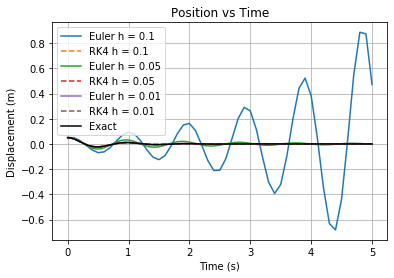

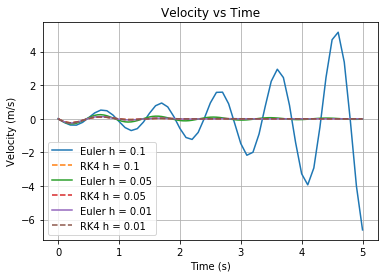

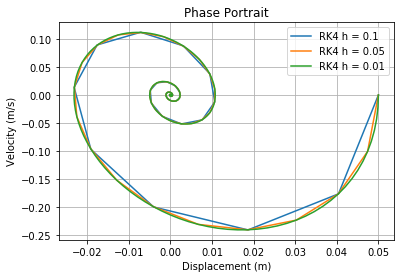

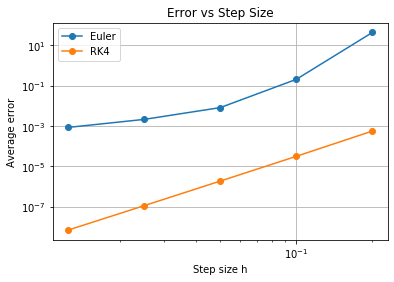

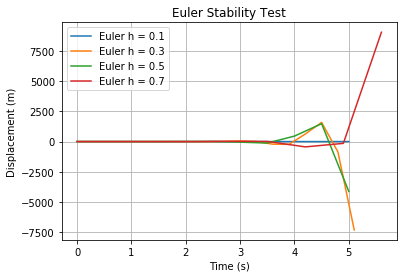

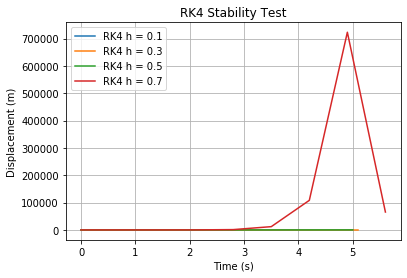

Largest stable Euler step size: 0.09999999999999999
Largest stable RK4 step size: 0.46
Euler error slope: 3.784750063576081
RK4 error slope: 4.0722202321671555


In [3]:
#PART 1/3
import numpy as np
import matplotlib.pyplot as plt

m = 338.5
c = 1070
k = 15000

y0 = 0.05
v0 = 0
t0 = 0
tf = 5

def a(y, v):
    return (-c * v - k * y) / m

def exact(t):
    wn = np.sqrt(k / m)
    z = c / (2 * np.sqrt(m * k))
    wd = wn * np.sqrt(1 - z**2)

    A = y0
    B = (v0 + z * wn * y0) / wd

    return np.exp(-z * wn * t) * (A * np.cos(wd * t) + B * np.sin(wd * t))

def euler(h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    v = np.zeros(len(t))

    y[0] = y0
    v[0] = v0

    for i in range(len(t) - 1):
        y[i + 1] = y[i] + h * v[i]
        v[i + 1] = v[i] + h * a(y[i], v[i])

    return t, y, v

def rk4(h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    v = np.zeros(len(t))

    y[0] = y0
    v[0] = v0

    for i in range(len(t) - 1):
        k1y = v[i]
        k1v = a(y[i], v[i])

        k2y = v[i] + 0.5 * h * k1v
        k2v = a(y[i] + 0.5 * h * k1y, v[i] + 0.5 * h * k1v)

        k3y = v[i] + 0.5 * h * k2v
        k3v = a(y[i] + 0.5 * h * k2y, v[i] + 0.5 * h * k2v)

        k4y = v[i] + h * k3v
        k4v = a(y[i] + h * k3y, v[i] + h * k3v)

        y[i + 1] = y[i] + h * (k1y + 2*k2y + 2*k3y + k4y) / 6
        v[i + 1] = v[i] + h * (k1v + 2*k2v + 2*k3v + k4v) / 6

    return t, y, v

h_list = [0.1, 0.05, 0.01]

plt.figure()
for h in h_list:
    t, y, v = euler(h)
    plt.plot(t, y, label="Euler h = " + str(h))

    t, y, v = rk4(h)
    plt.plot(t, y, "--", label="RK4 h = " + str(h))

t_exact = np.linspace(t0, tf, 1000)
plt.plot(t_exact, exact(t_exact), "k", label="Exact")
plt.title("Position vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for h in h_list:
    t, y, v = euler(h)
    plt.plot(t, v, label="Euler h = " + str(h))

    t, y, v = rk4(h)
    plt.plot(t, v, "--", label="RK4 h = " + str(h))

plt.title("Velocity vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for h in h_list:
    t, y, v = rk4(h)
    plt.plot(y, v, label="RK4 h = " + str(h))

plt.title("Phase Portrait")
plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()

errors_euler = []
errors_rk4 = []
h_errors = [0.2, 0.1, 0.05, 0.025, 0.0125]

for h in h_errors:
    t, y, v = euler(h)
    error = np.mean(abs(y - exact(t)))
    errors_euler.append(error)

    t, y, v = rk4(h)
    error = np.mean(abs(y - exact(t)))
    errors_rk4.append(error)

plt.figure()
plt.loglog(h_errors, errors_euler, "o-", label="Euler")
plt.loglog(h_errors, errors_rk4, "o-", label="RK4")
plt.title("Error vs Step Size")
plt.xlabel("Step size h")
plt.ylabel("Average error")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()

bad_steps = [0.1, 0.3, 0.5, 0.7]

for h in bad_steps:
    t, y, v = euler(h)
    plt.plot(t, y, label="Euler h = " + str(h))

plt.title("Euler Stability Test")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()

for h in bad_steps:
    t, y, v = rk4(h)
    plt.plot(t, y, label="RK4 h = " + str(h))

plt.title("RK4 Stability Test")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

def find_stable(method):
    h_values = np.arange(0.01, 1.01, 0.01)
    stable = []

    for h in h_values:
        t, y, v = method(h)

        if max(abs(y)) < 1:
            stable.append(h)

    return max(stable)

print("Largest stable Euler step size:", find_stable(euler))
print("Largest stable RK4 step size:", find_stable(rk4))

slope_euler = np.polyfit(np.log(h_errors), np.log(errors_euler), 1)[0]
slope_rk4 = np.polyfit(np.log(h_errors), np.log(errors_rk4), 1)[0]

print("Euler error slope:", slope_euler)
print("RK4 error slope:", slope_rk4)

**Section 1 - Introduction & Model Selection**

In this project, a spring-mass-damper system is used to model a real-world mechanical system. This type of system is commonly used in engineering applications such as vehicle suspensions and vibration control.

The second-order differential equation is:
        m(d^2y/dt^2)+c(dy/dt)+ky=0

where y(t) is displacement (m), m is mass (kg), c is damping coefficient (N·s/m), and k is spring constant (N/m)

To solve this numerically, the equation is rewritten as a system of first-order ODEs:

        y1=y, y2=dy/dt
        
        dy1/dt=y2
        
        dy2/dt=(-cy2-ky1)/m

The system is solved using Euler’s Forward Method and the fourth-order Runge-Kutta (RK4) method.

**Section 2 - Parameter Research & Justification**

The system represents a quarter-car suspension model, which simplifies the vehicle to one of its wheels and its associated mass.

| Parameter   | Value | Units |
| ----------- | ----- | ----- |
| Mass (m)    | 338.5 | kg    |
| Damping (c) | 1070  | N·s/m |
| Spring (k)  | 15000 | N/m   |

These values were chosen based on typical reported in mechanical and automotive engineering literature for quarter-car suspension models. The initial conditions are y(0) = 0.05 m, and v(0) = 0. These conditions represent the system being displaced upward and then being released, like driving over a bump.

**Section 3 - Numerical Methods Implementation**

The two numerical methods implemented here are:

**Euler's Method**: Uses the current slope to estimate the next value; simple but only accurate for first-order; errors with this method grow quickly
**Runge-Kutta (RK4)**: Calculates foru slopes at each step and combines them; reults in much higher accuracy and stability

-Both methods were implemented as separate functions with step sizes h = 0.1, 0.05, 0.01

**Section 4 - Solutions and Comparison**

The numerical solutions were compared using plots of position vs. time, velocity vs. time, and phase portraits.

Observations from Plots: RK4 closely mathces the analytical solution for each step size; Euler shows noticeable error for the larger step sizes; both methods become more accurate as step size decreases.

The position plots show that Euler's Method begins to deviate from the actual solution, while RK4 remains very close. The phase portrait shows a spiral moving toward equilibrium, which was expected for the damped system. RK4 produces smoother and more accurate results than Euler's Method overall.

**Section 5 - Stability Analysis**

Step Size Investigation:
Additional step sizes of h = 0.1, 0.3, 0.5, and 0.7 were tested. The results show that Euler is more unstable at larger step sizes, creating larger oscillations, while RK4 remains stable over a wider range. The maximum stable step size is estimated by checking when solutions are still bounded.

Error Analysis:
Error was found by comparing the numerical results to the analytical solution. The log-log plot of error vs. step size showed that Euler slope = 1 gives accuracy in the first-order, while RK4 slope = 4 gives accuracy in the fourth-order. These results mathc the theoretical expectations of O(h) and O(h^4) for Euler and RK4 respectively.

Physical Interpretation:
For larger step sizes, Euler's Method creates increasing oscillations in a damped system. Physically, the system should lose energy of time and eventually settle. The numerical method showing growth instead, which indicates instability. RK4 keeps the correct physical behavior by showing decay.

**Section 6 - Conclusions**
RK4 performed better than Euler's Method in both accuracy and stability. Euler is simple but needs very small step sizes while RK4 give accurate results even when step sizes are larger.

-Euler has lower cost per step, but RK4 is more efficient overall because it allows larger step sizes
-RK4 is recommended for oscillating systems or when your accuracy is important

Lessons Learned:

-Step size has an obvious effect on stability
-Higher-order methods greatly improve accuracy
-Numerical instability can cause incorrect physical results
